# 🧠 Notebook 08 — CNN Baseline All Splits

---

<div style="background: linear-gradient(135deg, #0f0c29 0%, #302b63 50%, #24243e 100%); padding: 24px 28px; border-radius: 16px; margin: 12px 0; border: 1px solid #e94560;">
<h2 style="color: #e94560; margin: 0 0 8px 0; font-size: 1.4em;">🧠 CNN Baseline All Splits</h2>
<h3 style="color: #a8dadc; margin: 0 0 16px 0; font-weight: 400; font-size: 1.05em;">Fase B — Eksperimen Model Deep Learning</h3>
<hr style="border: none; border-top: 1px solid #444; margin: 12px 0;">
<table style="color: #ccc; font-size: 0.9em; border-collapse: collapse; width: 100%;">
<tr><td style="padding: 4px 16px 4px 0; white-space:nowrap;">📍 Studi Kasus</td><td><strong style="color: #fff;">PT. XYZ Banjarmasin, Kalimantan Selatan</strong></td></tr>
<tr><td style="padding: 4px 16px 4px 0;">🎓 Mata Kuliah</td><td><strong style="color: #fff;">Tugas Akhir — ES234733</strong></td></tr>
<tr><td style="padding: 4px 16px 4px 0;">🏛 Institusi</td><td><strong style="color: #fff;">Departemen Sistem Informasi, FTEIC — ITS Surabaya</strong></td></tr>
<tr><td style="padding: 4px 16px 4px 0;">👤 Penulis</td><td><strong style="color: #fff;">Muhammad Iqbal Baiduri Yamani — NRP 5026221103</strong></td></tr>
<tr><td style="padding: 4px 16px 4px 0;">🧑‍🏫 Pembimbing</td><td><strong style="color: #fff;">Edwin Riksakomara, S.Kom., M.T.</strong></td></tr>
<tr><td style="padding: 4px 16px 4px 0;">📅 Tahun</td><td><strong style="color: #fff;">2025</strong></td></tr>
</table>
</div>

## 📌 Tujuan Notebook Ini

Notebook 08 menjalankan **CNN baseline** pada semua rasio split (`60:40`, `70:30`, `80:20`, `90:10`) dengan protokol berikut:

- Training pada train set masing-masing split
- Evaluasi final pada test set split terkait
- Evaluasi stabilitas melalui walk-forward CV dari artefak Notebook 07
- Metrik wajib: **MAPE (utama), MAE, RMSE, R²**

> Notebook ini dijalankan murni lokal (tanpa Colab/Drive/GPU dependency).

| # | Tahapan | Keterangan |
|---|---------|------------|
| 1 | Import & Setup | Seed, path, style, dan inisialisasi runtime lokal TensorFlow |
| 2 | Load Artifacts | `split_*.npz` dan `wf_cv_*.npz` |
| 3 | Build CNN Baseline | Arsitektur CNN tetap untuk semua split |
| 4 | Train + Evaluate | Train per split, evaluasi test + walk-forward CV |
| 5 | Save Artifacts | Model, metrik, prediksi, dan figur |
| 6 | Checklist | Verifikasi kelengkapan deliverable Pipeline |

## ⚙️ 1. Import Library, Reproducibility, dan GPU Setup

In [34]:
# ── Import Library & Setup ────────────────────────────────────
import os
import json
import random
import warnings
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import tensorflow as tf  # type: ignore[import-untyped]

# Reduksi warning internal TensorFlow/Keras
# (mis. deprecation/retracing warning dari logger tensorflow)
tf.get_logger().setLevel("ERROR")
try:
    tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)
except Exception:
    pass
logging.getLogger("tensorflow").setLevel(logging.ERROR)

# Hindari import submodule tensorflow.keras langsung agar warning Pylance berkurang
keras = tf.keras
Sequential = keras.Sequential
Input = keras.layers.Input
Conv1D = keras.layers.Conv1D
BatchNormalization = keras.layers.BatchNormalization
GlobalAveragePooling1D = keras.layers.GlobalAveragePooling1D
Dense = keras.layers.Dense
Dropout = keras.layers.Dropout
Adam = keras.optimizers.Adam
EarlyStopping = keras.callbacks.EarlyStopping
ReduceLROnPlateau = keras.callbacks.ReduceLROnPlateau
mixed_precision = keras.mixed_precision
regularizers = keras.regularizers

warnings.filterwarnings("ignore")
os.environ["PYTHONHASHSEED"] = "42"

# ── Reproducibility ───────────────────────────────────────────
GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
tf.random.set_seed(GLOBAL_SEED)

# ── Runtime Setup (lokal CPU) ─────────────────────────────
gpus = []
GPU_ACTIVE = False
mixed_precision.set_global_policy("float32")

# ── Path Konfigurasi Lokal ────────────────────────────────────
IS_COLAB = False
ROOT_DIR = Path(".").resolve().parent

PATHS = {
    "root": ROOT_DIR,
    "logs": ROOT_DIR / "logs",
    "outputs": ROOT_DIR / "outputs",
    "figures": ROOT_DIR / "outputs" / "figures",
    "models": ROOT_DIR / "outputs" / "models",
    "metrics": ROOT_DIR / "outputs" / "metrics",
    "splits": ROOT_DIR / "outputs" / "splits",
    "cv_folds": ROOT_DIR / "outputs" / "cv_folds",
    "predictions": ROOT_DIR / "results" / "predictions",
}
for p in PATHS.values():
    if isinstance(p, Path):
        p.mkdir(parents=True, exist_ok=True)

SPLIT_LABELS = ["60:40", "70:30", "80:20", "90:10"]
K_FOLDS = 5
TAU = 8

# ── Matplotlib Style ─────────────────────────────────────────
ACCENT = "#e94560"
ACCENT2 = "#a8dadc"
plt.rcParams.update({
    "figure.facecolor": "#1a1a2e",
    "axes.facecolor": "#16213e",
    "axes.edgecolor": "#444",
    "axes.labelcolor": "#ccc",
    "xtick.color": "#aaa",
    "ytick.color": "#aaa",
    "text.color": "#ddd",
    "grid.color": "#2a2a4a",
    "grid.linestyle": "--",
    "grid.linewidth": 0.5,
    "axes.grid": True,
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print("=" * 76)
print("  SETUP — NOTEBOOK 08 (CNN BASELINE ALL SPLITS)")
print("=" * 76)
print("  Env              : Lokal")
print(f"  TensorFlow       : {tf.__version__}")
print("  GPU terdeteksi   : 0")
print("    - CPU mode aktif")
print(f"  Mixed precision  : {mixed_precision.global_policy().name}")
print(f"  GLOBAL_SEED      : {GLOBAL_SEED}")
print("=" * 76)

  SETUP — NOTEBOOK 08 (CNN BASELINE ALL SPLITS)
  Env              : Lokal
  TensorFlow       : 2.21.0
  GPU terdeteksi   : 0
    - CPU mode aktif
  Mixed precision  : float32
  GLOBAL_SEED      : 42


## 📂 2. Load Artefak Split dan Walk-Forward CV

In [35]:
# ── Load split + walk-forward artifacts ──────────────────────
split_artifacts = {}
cv_artifacts = {}

for label in SPLIT_LABELS:
    split_path = PATHS["splits"] / f"split_{label.replace(':', '_')}.npz"
    cv_path = PATHS["cv_folds"] / f"wf_cv_{label.replace(':', '_')}.npz"

    if not split_path.exists():
        raise FileNotFoundError(f"Artefak split tidak ditemukan: {split_path}")
    if not cv_path.exists():
        raise FileNotFoundError(f"Artefak walk-forward tidak ditemukan: {cv_path}")

    split_npz = np.load(split_path, allow_pickle=True)
    cv_npz = np.load(cv_path, allow_pickle=True)

    split_artifacts[label] = {
        "X_train": split_npz["X_train"].astype(np.float32),
        "y_train": split_npz["y_train"].astype(np.float32),
        "X_test": split_npz["X_test"].astype(np.float32),
        "y_test": split_npz["y_test"].astype(np.float32),
        "split_path": split_path,
    }

    cv_artifacts[label] = {
        "train_end_indices": cv_npz["train_end_indices"].astype(int),
        "val_start_indices": cv_npz["val_start_indices"].astype(int),
        "val_end_indices": cv_npz["val_end_indices"].astype(int),
        "k_folds": int(cv_npz["k_folds"]),
        "initial_train_size": int(cv_npz["initial_train_size"]),
    }

rows = []
for label in SPLIT_LABELS:
    art = split_artifacts[label]
    cv = cv_artifacts[label]
    rows.append({
        "split": label,
        "X_train": str(art["X_train"].shape),
        "y_train": str(art["y_train"].shape),
        "X_test": str(art["X_test"].shape),
        "y_test": str(art["y_test"].shape),
        "k_folds": cv["k_folds"],
        "initial_train_size": cv["initial_train_size"],
    })

display(pd.DataFrame(rows))
print("=" * 72)
print("  ✅ Artefak split dan walk-forward CV berhasil dimuat.")
print("=" * 72)

,split,X_train,y_train,X_test,y_test,k_folds,initial_train_size
0,60:40,"(213, 8)","(213,)","(143, 8)","(143,)",5,38
1,70:30,"(249, 8)","(249,)","(107, 8)","(107,)",5,44
2,80:20,"(284, 8)","(284,)","(72, 8)","(72,)",5,49
3,90:10,"(320, 8)","(320,)","(36, 8)","(36,)",5,55


  ✅ Artefak split dan walk-forward CV berhasil dimuat.


## 🧱 3. Helper Function: Scaling, Metrics, dan Model CNN

In [47]:

# ── Helper functions ──────────────────────────────────────────
# Tuning progress output
TRAIN_VERBOSE = 1   # 1 = progress bar per epoch, 0 = silent
CV_VERBOSE = 0      # 1 = progress bar CV fold, 0 = ringkas

L2 = regularizers.l2

# ── Per-window (instance) normalization ──────────────────────
# Normalisasi berdasarkan statistik SETIAP window individual, bukan global.
# Membuat model belajar pola RELATIF → robust terhadap downward trend.
def normalize_per_window(X, y):
    """
    Instance normalization: setiap sample dinormalisasi oleh mean/std window-nya sendiri.
    X: (n_samples, tau) — tiap baris adalah window tau lag
    Mengembalikan X_norm, y_norm, dan per-sample mu/sigma untuk inverse transform.
    """
    mu = X.mean(axis=1)           # (n_samples,)
    sigma = X.std(axis=1) + 1e-8  # (n_samples,)

    X_norm = (X - mu[:, None]) / sigma[:, None]  # normalize tiap window
    y_norm = (y - mu) / sigma                    # target dinormalisasi dengan stats SAMA

    return X_norm.astype(np.float32), y_norm.astype(np.float32), mu.astype(np.float32), sigma.astype(np.float32)


def inverse_y_per_window(y_norm, mu, sigma):
    """Inverse transform dari per-window normalization."""
    return (y_norm * sigma + mu).astype(np.float32)


def predict_no_retrace(model, X_3d):
    # Inference langsung tanpa model.predict() untuk mengurangi retracing warning
    y = model(X_3d, training=False)
    return tf.reshape(y, [-1]).numpy().astype(np.float32)


def regression_metrics(y_true, y_pred, eps=1e-8):
    y_true = y_true.astype(np.float64)
    y_pred = y_pred.astype(np.float64)

    mae = float(np.mean(np.abs(y_true - y_pred)))
    rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
    mape = float(np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), eps, None))) * 100.0)

    ss_res = float(np.sum((y_true - y_pred) ** 2))
    ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2))
    r2 = float(1.0 - (ss_res / ss_tot)) if ss_tot > 0 else 0.0

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "R2": r2,
    }


def build_cnn_baseline(
    input_steps=8,
    filters=16,
    kernel_size=3,
    dense_units=16,
    dropout=0.25,
    lr=5e-4,
    l2_reg=0.0,
):
    """CNN baseline — satu Conv1D layer dengan per-window normalization."""
    model = Sequential([
        Input(shape=(input_steps, 1)),
        Conv1D(
            filters=filters,
            kernel_size=kernel_size,
            activation="relu",
            padding="causal",
        ),
        GlobalAveragePooling1D(),
        Dense(dense_units, activation="relu"),
        Dropout(dropout),
        Dense(1, dtype="float32"),
    ])
    model.compile(optimizer=Adam(learning_rate=lr, clipnorm=1.0), loss="mse")
    return model


def make_lr_callback(lr_patience=10, monitor="loss"):
    """Hanya ReduceLROnPlateau — tanpa EarlyStopping (tidak ada val_loss)."""
    lr_sched = ReduceLROnPlateau(
        monitor=monitor,
        factor=0.5,
        patience=lr_patience,
        min_lr=1e-6,
        mode="min",
        verbose=0,
    )
    return lr_sched


print("✅ Helper function siap (per-window normalization).")
print(f"✅ TRAIN_VERBOSE={TRAIN_VERBOSE}, CV_VERBOSE={CV_VERBOSE}")


✅ Helper function siap (per-window normalization).
✅ TRAIN_VERBOSE=1, CV_VERBOSE=0


## 🚀 4. Train & Evaluate CNN Baseline untuk Semua Split

In [48]:

# ── Training dan evaluasi per split ───────────────────────────
# Per-window normalization: setiap sample dinormalisasi oleh statistik window-nya
# sendiri → model belajar pola RELATIF, robust terhadap downward trend.
EPOCHS = 150
BATCH_SIZE = 16

result_rows = []
cv_rows = []
pred_store = {}
train_history_store = {}

for split_idx, label in enumerate(SPLIT_LABELS, start=1):
    print("\n" + "=" * 76)
    print(f"[Split {split_idx}/{len(SPLIT_LABELS)}] Mulai training split {label}")
    print("=" * 76)

    art = split_artifacts[label]
    cv = cv_artifacts[label]

    X_train = art["X_train"]
    y_train = art["y_train"]
    X_test = art["X_test"]
    y_test = art["y_test"]

    # Per-window (instance) normalization — robust terhadap scale shift
    X_train_n, y_train_n, _, _ = normalize_per_window(X_train, y_train)
    X_test_n, _, test_mu, test_sigma = normalize_per_window(X_test, y_test)

    X_train_n = X_train_n[..., None]
    X_test_n = X_test_n[..., None]

    tf.keras.backend.clear_session()
    model = build_cnn_baseline(
        input_steps=TAU,
        filters=16,
        kernel_size=3,
        dense_units=16,
        dropout=0.25,
        lr=5e-4,
        l2_reg=0.0,
    )

    # Hanya ReduceLROnPlateau pada train loss — tanpa EarlyStopping
    lr_sched = make_lr_callback(lr_patience=10, monitor="loss")

    hist = model.fit(
        X_train_n,
        y_train_n,
        shuffle=False,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[lr_sched],
        verbose=TRAIN_VERBOSE,
    )

    y_test_pred_n = predict_no_retrace(model, X_test_n)
    y_test_pred = inverse_y_per_window(y_test_pred_n, test_mu, test_sigma)
    metrics_test = regression_metrics(y_test, y_test_pred)

    # Walk-forward CV metrics
    fold_mapes = []
    fold_maes = []
    fold_rmses = []
    fold_r2s = []

    for fold_id, (train_end, val_start, val_end_excl) in enumerate(
        zip(cv["train_end_indices"], cv["val_start_indices"], cv["val_end_indices"]),
        start=1,
    ):
        if CV_VERBOSE == 0:
            print(f"  - CV fold {fold_id}/{K_FOLDS} (split {label})")

        tr_idx = np.arange(0, int(train_end), dtype=int)
        va_idx = np.arange(int(val_start), int(val_end_excl), dtype=int)

        X_tr = X_train[tr_idx]
        y_tr = y_train[tr_idx]
        X_va = X_train[va_idx]
        y_va = y_train[va_idx]

        X_tr_n, y_tr_n, _, _ = normalize_per_window(X_tr, y_tr)
        X_va_n, _, va_mu, va_sigma = normalize_per_window(X_va, y_va)

        X_tr_n = X_tr_n[..., None]
        X_va_n = X_va_n[..., None]

        tf.keras.backend.clear_session()
        cv_model = build_cnn_baseline(
            input_steps=TAU,
            filters=16,
            kernel_size=3,
            dense_units=16,
            dropout=0.25,
            lr=5e-4,
            l2_reg=0.0,
        )

        cv_lr = make_lr_callback(lr_patience=8, monitor="loss")

        cv_model.fit(
            X_tr_n,
            y_tr_n,
            shuffle=False,
            epochs=100,
            batch_size=BATCH_SIZE,
            callbacks=[cv_lr],
            verbose=CV_VERBOSE,
        )

        y_va_pred_n = predict_no_retrace(cv_model, X_va_n)
        y_va_pred = inverse_y_per_window(y_va_pred_n, va_mu, va_sigma)
        m = regression_metrics(y_va, y_va_pred)

        fold_mapes.append(m["MAPE"])
        fold_maes.append(m["MAE"])
        fold_rmses.append(m["RMSE"])
        fold_r2s.append(m["R2"])

        cv_rows.append({
            "split": label,
            "fold": fold_id,
            "MAE": m["MAE"],
            "RMSE": m["RMSE"],
            "MAPE": m["MAPE"],
            "R2": m["R2"],
        })

    # Save model per split
    model_path = PATHS["models"] / f"nb08_cnn_baseline_{label.replace(':', '_')}.keras"
    model.save(model_path)

    result_rows.append({
        "split": label,
        "train_size": len(y_train),
        "test_size": len(y_test),
        "MAE_test": metrics_test["MAE"],
        "RMSE_test": metrics_test["RMSE"],
        "MAPE_test": metrics_test["MAPE"],
        "R2_test": metrics_test["R2"],
        "MAPE_cv_mean": float(np.mean(fold_mapes)),
        "MAPE_cv_std": float(np.std(fold_mapes)),
        "MAE_cv_mean": float(np.mean(fold_maes)),
        "RMSE_cv_mean": float(np.mean(fold_rmses)),
        "R2_cv_mean": float(np.mean(fold_r2s)),
        "epochs_trained": len(hist.history["loss"]),
        "model_path": str(model_path.relative_to(ROOT_DIR)),
    })

    pred_store[label] = {
        "y_true": y_test.astype(np.float32),
        "y_pred": y_test_pred.astype(np.float32),
    }
    train_history_store[label] = {
        "loss": [float(v) for v in hist.history["loss"]],
    }

result_df = pd.DataFrame(result_rows).sort_values("MAPE_test")
cv_df = pd.DataFrame(cv_rows)

display(result_df)
print("=" * 76)
print("  ✅ Training CNN baseline selesai untuk semua split.")
print("  🏆 Ranking sementara (MAPE test):")
for i, row in result_df.reset_index(drop=True).iterrows():
    print(f"    {i+1}. Split {row['split']} -> MAPE={row['MAPE_test']:.4f}%, R²={row['R2_test']:.4f}")
print("=" * 76)



[Split 1/4] Mulai training split 60:40
Epoch 1/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.0097 - learning_rate: 5.0000e-04
Epoch 2/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.0152 - learning_rate: 5.0000e-04
Epoch 3/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.0315 - learning_rate: 5.0000e-04
Epoch 4/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.0235 - learning_rate: 5.0000e-04
Epoch 5/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.0256 - learning_rate: 5.0000e-04
Epoch 6/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.0255 - learning_rate: 5.0000e-04
Epoch 7/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.0082 - learning_rate: 5.0000e-04
Epoch 8/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.0063 - learning_rate: 5.0000e-04
Epoch 9/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.0169 - learning_rate: 5.0000e-04
Epoch 10/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.9997 - learning_rate: 5.0000e-04
Epoch 11/150
14/14 

,split,train_size,test_size,MAE_test,RMSE_test,MAPE_test,R2_test,MAPE_cv_mean,MAPE_cv_std,MAE_cv_mean,RMSE_cv_mean,R2_cv_mean,epochs_trained,model_path
3,90:10,320,36,7219.716797,9107.474081,18.731340,-0.146160,32.195867,11.022096,11211.993190,14814.850681,-0.112116,150,outputs\models\nb08_cnn_baseline_90_10.keras
2,80:20,284,72,7062.300673,9659.349842,26.812000,-0.117224,30.952460,11.841289,11697.726695,15558.284919,-0.085156,150,outputs\models\nb08_cnn_baseline_80_20.keras
0,60:40,213,143,7679.678049,10303.682016,34.998867,-0.127232,27.580106,7.522358,13613.644018,17803.592933,-0.118315,150,outputs\models\nb08_cnn_baseline_60_40.keras
1,70:30,249,107,7748.077066,10530.064105,38.602515,-0.120109,26.872962,4.336425,12402.581250,16329.984427,-0.152477,150,outputs\models\nb08_cnn_baseline_70_30.keras


  ✅ Training CNN baseline selesai untuk semua split.
  🏆 Ranking sementara (MAPE test):
    1. Split 90:10 -> MAPE=18.7313%, R²=-0.1462
    2. Split 80:20 -> MAPE=26.8120%, R²=-0.1172
    3. Split 60:40 -> MAPE=34.9989%, R²=-0.1272
    4. Split 70:30 -> MAPE=38.6025%, R²=-0.1201


## 📊 5. Visualisasi Prediksi vs Aktual

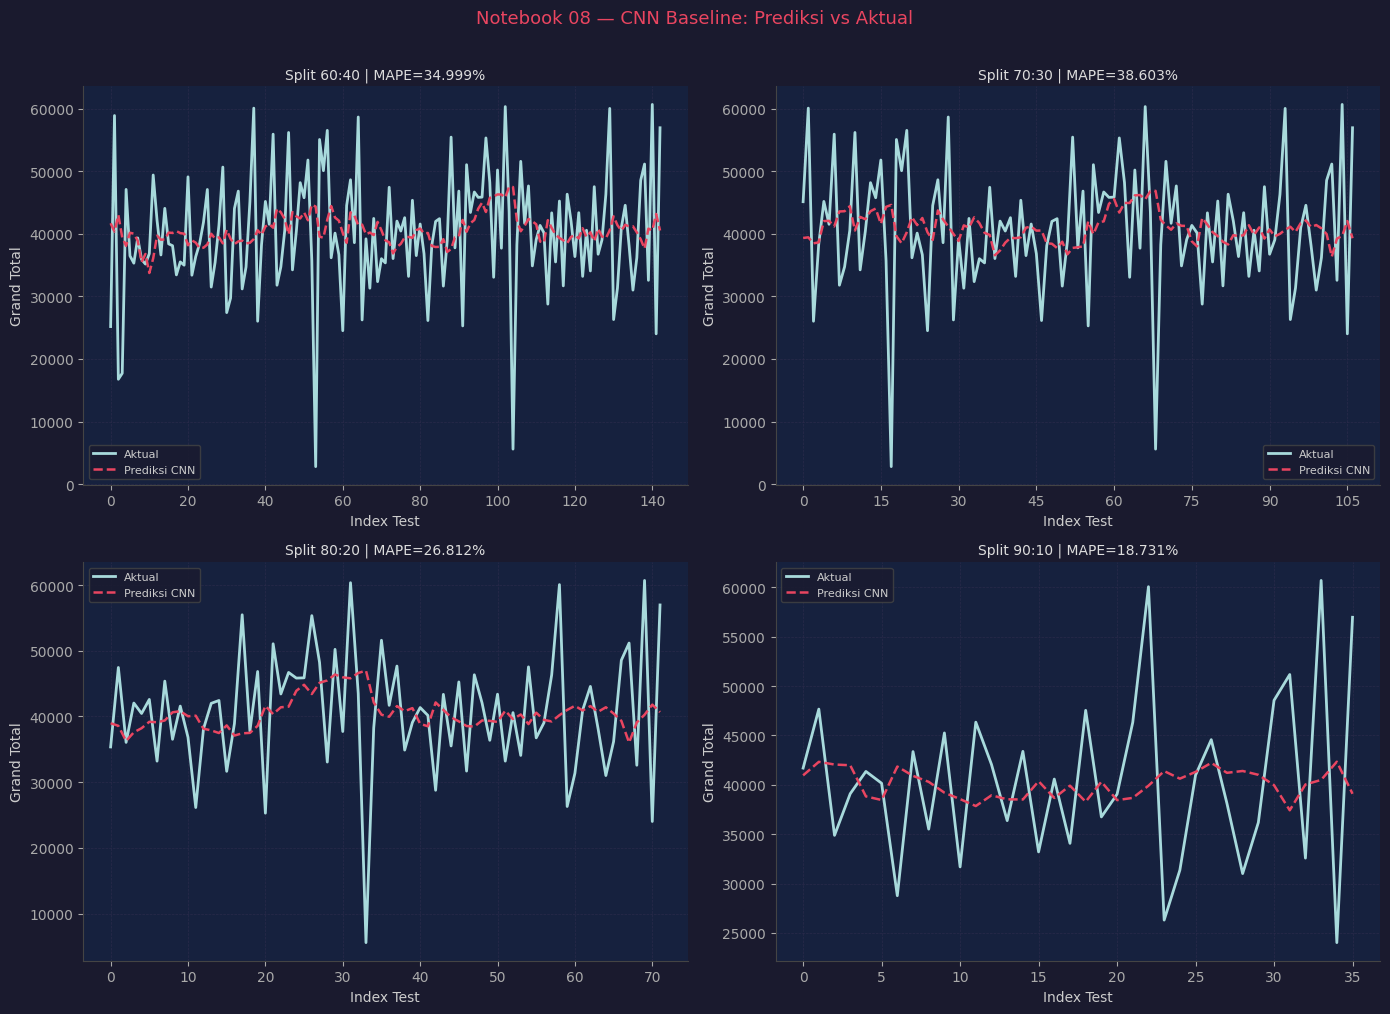

✅ Figur tersimpan: C:\Users\mikba\Downloads\Semester 7\Pra Tugas Akhir (Retno Aulia Vinarti)\Repository\CNN-BiLSTM-GA-Sales-Forecasting\outputs\figures\nb08_cnn_baseline_predictions.png


In [51]:
# ── Visualisasi prediksi vs aktual per split ─────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10), facecolor="#1a1a2e")
axes = axes.flatten()

for ax, label in zip(axes, SPLIT_LABELS):
    yt = pred_store[label]["y_true"]
    yp = pred_store[label]["y_pred"]
    ax.set_facecolor("#16213e")

    ax.plot(yt, color=ACCENT2, linewidth=2.0, label="Aktual")
    ax.plot(yp, color=ACCENT, linewidth=1.8, linestyle="--", label="Prediksi CNN")

    mape_val = float(result_df.loc[result_df["split"] == label, "MAPE_test"].iloc[0])
    ax.set_title(f"Split {label} | MAPE={mape_val:.3f}%", color="#ddd", fontsize=10)
    ax.set_xlabel("Index Test", color="#ccc")
    ax.set_ylabel("Grand Total", color="#ccc")
    ax.legend(fontsize=8, labelcolor="#ccc", facecolor="#1a1a2e", edgecolor="#444")
    ax.xaxis.set_major_locator(mticker.MaxNLocator(8))
    for sp in ax.spines.values():
        sp.set_color("#444")

fig.suptitle("Notebook 08 — CNN Baseline: Prediksi vs Aktual", color="#e94560", fontsize=13, y=1.01)
plt.tight_layout()
fig_path = PATHS["figures"] / "nb08_cnn_baseline_predictions.png"
fig.savefig(fig_path, dpi=160, bbox_inches="tight", facecolor="#1a1a2e")
plt.show()

print(f"✅ Figur tersimpan: {fig_path}")

## 💾 6. Simpan Artefak Notebook 08

In [50]:
# ── Simpan metrik, prediksi, dan metadata ────────────────────
metrics_csv_path = PATHS["metrics"] / "nb08_cnn_baseline_metrics.csv"
metrics_json_path = PATHS["metrics"] / "nb08_cnn_baseline_metrics.json"
cv_csv_path = PATHS["metrics"] / "nb08_cnn_baseline_cv_metrics.csv"
pred_npz_path = PATHS["predictions"] / "nb08_cnn_baseline_predictions.npz"
history_json_path = PATHS["logs"] / "nb08_training_history.json"

result_df.to_csv(metrics_csv_path, index=False)
cv_df.to_csv(cv_csv_path, index=False)

payload = {
    "notebook": "08 - CNN Baseline All Splits",
    "timestamp": __import__("datetime").datetime.now().isoformat(timespec="seconds"),
    "gpu_count": len(gpus),
    "mixed_precision": mixed_precision.global_policy().name,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "k_folds": K_FOLDS,
    "results": result_df.to_dict(orient="records"),
}
with open(metrics_json_path, "w", encoding="utf-8") as f:
    json.dump(payload, f, indent=2, ensure_ascii=False)

npz_kwargs = {}
for label in SPLIT_LABELS:
    key = label.replace(":", "_")
    npz_kwargs[f"y_true_{key}"] = pred_store[label]["y_true"]
    npz_kwargs[f"y_pred_{key}"] = pred_store[label]["y_pred"]
np.savez(pred_npz_path, **npz_kwargs)

with open(history_json_path, "w", encoding="utf-8") as f:
    json.dump(train_history_store, f, indent=2, ensure_ascii=False)

print("=" * 72)
print("  SIMPAN ARTEFAK — NOTEBOOK 08")
print("=" * 72)
print(f"  ✅ Metrics CSV    : {metrics_csv_path}")
print(f"  ✅ Metrics JSON   : {metrics_json_path}")
print(f"  ✅ CV Metrics CSV : {cv_csv_path}")
print(f"  ✅ Predictions NPZ: {pred_npz_path}")
print(f"  ✅ History JSON   : {history_json_path}")
print("=" * 72)

  SIMPAN ARTEFAK — NOTEBOOK 08
  ✅ Metrics CSV    : C:\Users\mikba\Downloads\Semester 7\Pra Tugas Akhir (Retno Aulia Vinarti)\Repository\CNN-BiLSTM-GA-Sales-Forecasting\outputs\metrics\nb08_cnn_baseline_metrics.csv
  ✅ Metrics JSON   : C:\Users\mikba\Downloads\Semester 7\Pra Tugas Akhir (Retno Aulia Vinarti)\Repository\CNN-BiLSTM-GA-Sales-Forecasting\outputs\metrics\nb08_cnn_baseline_metrics.json
  ✅ CV Metrics CSV : C:\Users\mikba\Downloads\Semester 7\Pra Tugas Akhir (Retno Aulia Vinarti)\Repository\CNN-BiLSTM-GA-Sales-Forecasting\outputs\metrics\nb08_cnn_baseline_cv_metrics.csv
  ✅ Predictions NPZ: C:\Users\mikba\Downloads\Semester 7\Pra Tugas Akhir (Retno Aulia Vinarti)\Repository\CNN-BiLSTM-GA-Sales-Forecasting\results\predictions\nb08_cnn_baseline_predictions.npz
  ✅ History JSON   : C:\Users\mikba\Downloads\Semester 7\Pra Tugas Akhir (Retno Aulia Vinarti)\Repository\CNN-BiLSTM-GA-Sales-Forecasting\logs\nb08_training_history.json


## ✅ 7. Checklist Akhir Notebook 08

In [52]:
# ── Checklist akhir Notebook 08 ──────────────────────────────
trained_all_splits = result_df.shape[0] == 4
mape_complete = result_df["MAPE_test"].notna().all()
mae_complete = result_df["MAE_test"].notna().all()
rmse_complete = result_df["RMSE_test"].notna().all()
r2_complete = result_df["R2_test"].notna().all()

artifacts_ok = all([
    metrics_csv_path.exists(),
    metrics_json_path.exists(),
    cv_csv_path.exists(),
    pred_npz_path.exists(),
    fig_path.exists(),
])

checklist = [
    ("Training CNN per split selesai", trained_all_splits),
    ("MAPE per split tersedia", mape_complete),
    ("MAE per split tersedia", mae_complete),
    ("RMSE per split tersedia", rmse_complete),
    ("R² per split tersedia", r2_complete),
    ("Artefak metrik, prediksi, dan figur tersimpan", artifacts_ok),
]

print("=" * 60)
print("  CHECKLIST NOTEBOOK 08")
print("=" * 60)
all_pass = True
for label, status in checklist:
    icon = "✅" if status else "❌"
    if not status:
        all_pass = False
    print(f"  {icon}  {label}")
print("=" * 60)
if all_pass:
    print("  ✅ SEMUA CHECKLIST LULUS — Notebook 08 selesai!")
    print("     Lanjutkan ke Notebook 09 — CNN + GA All Splits.")
else:
    print("  ❌ Ada checklist yang gagal — periksa output di atas.")
print("=" * 60)

  CHECKLIST NOTEBOOK 08
  ✅  Training CNN per split selesai
  ✅  MAPE per split tersedia
  ✅  MAE per split tersedia
  ✅  RMSE per split tersedia
  ✅  R² per split tersedia
  ✅  Artefak metrik, prediksi, dan figur tersimpan
  ✅ SEMUA CHECKLIST LULUS — Notebook 08 selesai!
     Lanjutkan ke Notebook 09 — CNN + GA All Splits.


---

## 🔗 Navigasi Pipeline

| | Notebook |
|--|----------|
| ← | **[07 - Walk-Forward CV Builder](./07%20-%20Walk-Forward%20CV%20Builder.ipynb)** |
| **→** | **[09 - CNN + GA All Splits](./09%20-%20CNN%20%2B%20GA%20All%20Splits.ipynb)** |

---

<div style="text-align: center; color: #888; font-size: 0.85em; padding: 12px 0;">
Notebook 08 — CNN Baseline All Splits &nbsp;|&nbsp;
CNN–BiLSTM + GA Sales Forecasting &nbsp;|&nbsp;
Departemen Sistem Informasi ITS Surabaya &nbsp;|&nbsp; 2025
</div>